In [1]:
from google.colab import drive
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
drive_base_dir = '/content/drive/MyDrive/project/autoscout'

In [5]:
drive_data_dir = drive_base_dir+'/data'
drive_model_dir = drive_base_dir+'/model'
drive_plot_dir = drive_base_dir+'/plot'
drive_script_dir = drive_base_dir+'/script'

In [6]:
!jupyter nbconvert --to script '{drive_base_dir}/outlier_analysis.ipynb'
!mv '{drive_base_dir}/outlier_analysis.py' '{drive_script_dir}'

[NbConvertApp] Converting notebook /content/drive/MyDrive/project/autoscout/outlier_analysis.ipynb to script
[NbConvertApp] Writing 12672 bytes to /content/drive/MyDrive/project/autoscout/outlier_analysis.py


### Dataset Import

In [7]:
df = pd.read_csv(drive_data_dir+'/data_fill.csv')

In [8]:
df.head()

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
0,Audi A1,Sedans,VAT deductible,2.0,Used,Yes,Black,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.3,3.5,Germany,"Bluetooth,Hands-free equipment,On-board comput...","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Catalytic Converter,Voice Control",15770,56013.0,66.0,1422.0,0.0,1220.0,5.0,5.0,3.0,5.0,3.0
1,Audi A1,Sedans,Price negotiable,1.0,Used,No,Red,Metallic,Cloth,Grey,Automatic,Gasoline,129.0,Euro 6,4.0,Front,5.6,7.1,4.7,Germany,"Bluetooth,Hands-free equipment,On-board comput...","ABS,Central door lock,Central door lock with r...","Air conditioning,Automatic climate control,Hil...","Alloy wheels,Sport seats,Sport suspension,Voic...",14500,80000.0,141.0,1798.0,0.0,1255.0,3.0,4.0,4.0,7.0,2.0
2,Audi A1,Sedans,VAT deductible,1.0,Used,No,Black,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.4,3.4,Germany,"MP3,On-board computer","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Cruise control,Electrical sid...","Alloy wheels,Voice Control",14640,83450.0,85.0,1598.0,0.0,1195.0,4.0,4.0,3.0,5.0,3.0
3,Audi A1,Sedans,Missing,1.0,Used,No,Brown,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.3,3.5,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Alarm system,Central door lock with remote...","Air suspension,Armrest,Auxiliary heating,Elect...","Alloy wheels,Sport seats,Voice Control",14500,73000.0,66.0,1422.0,0.0,1195.0,3.0,4.0,3.0,6.0,3.0
4,Audi A1,Sedans,Missing,1.0,Used,Yes,Black,Metallic,Cloth,Black,Automatic,Diesel,109.0,Euro 6,4.0,Front,4.1,4.6,3.8,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Central door lock,Driver-side airbag,Elect...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Sport package,Sport suspension,Vo...",16790,16200.0,66.0,1422.0,0.0,1195.0,5.0,5.0,3.0,5.0,3.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15919 non-null  object 
 1   body_type            15919 non-null  object 
 2   vat                  15919 non-null  object 
 3   prev_owner           15919 non-null  float64
 4   type                 15919 non-null  object 
 5   inspection_new       15919 non-null  object 
 6   body_color           15919 non-null  object 
 7   paint_type           15919 non-null  object 
 8   upholstery_texture   15919 non-null  object 
 9   upholstery_color     15919 non-null  object 
 10  gearing_type         15919 non-null  object 
 11  fuel                 15919 non-null  object 
 12  co2_emission         15919 non-null  float64
 13  emission_class       15919 non-null  object 
 14  emission_label       15919 non-null  float64
 15  drive_chain          15919 non-null 

### Helper function

In [10]:
def fill_one_stage(df, group_col, target_col, method):
    df_fill = df.copy()

    supported_methods = ['mean', 'median', 'mode', 'ffill', 'bfill']

    if method not in supported_methods:
        raise ValueError(f"Method '{method}' not supported. Choose from: {', '.join(supported_methods)}")

    nan_count_initial = df_fill[target_col].isnull().sum()

    if method == 'mode':
        fill_value = df_fill.groupby(group_col)[target_col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        df_fill[target_col] = df_fill[target_col].fillna(fill_value)

    elif method in ['mean', 'median']:
        fill_value = df_fill.groupby(group_col)[target_col].transform(method)
        df_fill[target_col] = df_fill[target_col].fillna(fill_value)

    elif method == 'ffill':
        df_fill[target_col] = df_fill.groupby(group_col)[target_col].transform(lambda x: x.ffill().bfill())

    elif method == 'bfill':
        df_fill[target_col] = df_fill.groupby(group_col)[target_col].transform(lambda x: x.bfill().ffill())

    nan_count_after_group = df_fill[target_col].isnull().sum()

    if nan_count_after_group > 0:

        if method == 'mode':
            fill_value_globe = df_fill[target_col].mode().iloc[0] if not df_fill[target_col].mode().empty else np.nan
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'mean':
            fill_value_globe = df_fill[target_col].mean()
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'median':
            fill_value_globe = df_fill[target_col].median()
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'ffill':
            df_fill[target_col].ffill(inplace=True)
            df_fill[target_col].bfill(inplace=True)

        elif method == 'bfill':
            df_fill[target_col].bfill(inplace=True)
            df_fill[target_col].ffill(inplace=True)

    nan_count_final = df_fill[target_col].isnull().sum()

    return df_fill

In [11]:
def fill_two_stage(df, group_col1, group_col2, target_col, method):
    df_fill = df.copy()

    supported_methods = ['mean', 'median', 'mode', 'ffill', 'bfill']
    if method not in supported_methods:
        raise ValueError(f"Method '{method}' not supported. Choose from: {', '.join(supported_methods)}")

    nan_count_initial = df_fill[target_col].isnull().sum()

    if method == 'mode':
        fill_value = df_fill.groupby([group_col1, group_col2])[target_col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        df_fill[target_col] = df_fill[target_col].fillna(fill_value)
    elif method in ['mean', 'median']:
        fill_value = df_fill.groupby([group_col1, group_col2])[target_col].transform(method)
        df_fill[target_col] = df_fill[target_col].fillna(fill_value)
    elif method == 'ffill':
        df_fill[target_col] = df_fill.groupby([group_col1, group_col2])[target_col].transform(lambda x: x.ffill().bfill())
    elif method == 'bfill':
        df_fill[target_col] = df_fill.groupby([group_col1, group_col2])[target_col].transform(lambda x: x.bfill().ffill())

    nan_count_level1 = df_fill[target_col].isnull().sum()

    if nan_count_level1 > 0:
        if method == 'mode':
            fill_value_group = df_fill.groupby(group_col1)[target_col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_group)
        elif method in ['mean', 'median']:
            fill_value_group = df_fill.groupby(group_col1)[target_col].transform(method)
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_group)
        elif method == 'ffill':
            df_fill[target_col] = df_fill.groupby(group_col1)[target_col].transform(lambda x: x.ffill().bfill())
        elif method == 'bfill':
            df_fill[target_col] = df_fill.groupby(group_col1)[target_col].transform(lambda x: x.bfill().ffill())

    nan_count_level2 = df_fill[target_col].isnull().sum()

    if nan_count_level2 > 0:
        if method == 'mode':
            fill_value_globe = df_fill[target_col].mode().iloc[0] if not df_fill[target_col].mode().empty else np.nan
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'mean':
            fill_value_globe = df_fill[target_col].mean()
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'median':
            fill_value_globe = df_fill[target_col].median()
            df_fill[target_col] = df_fill[target_col].fillna(fill_value_globe)

        elif method == 'ffill':
            df_fill[target_col].ffill(inplace=True)
            df_fill[target_col].bfill(inplace=True)

        elif method == 'bfill':
            df_fill[target_col].bfill(inplace=True)
            df_fill[target_col].ffill(inplace=True)

    nan_count_final = df_fill[target_col].isnull().sum()

    return df_fill


### Outlier correction and analysis

#### Column: km

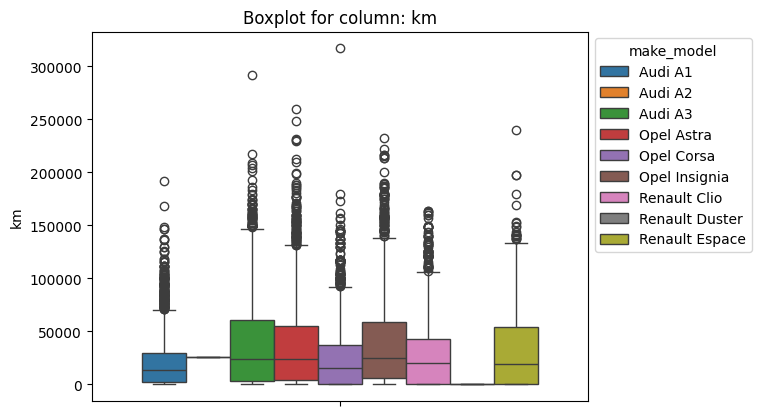

In [12]:
ax = sns.boxplot(df, y='km', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: km');

#### Column: weight


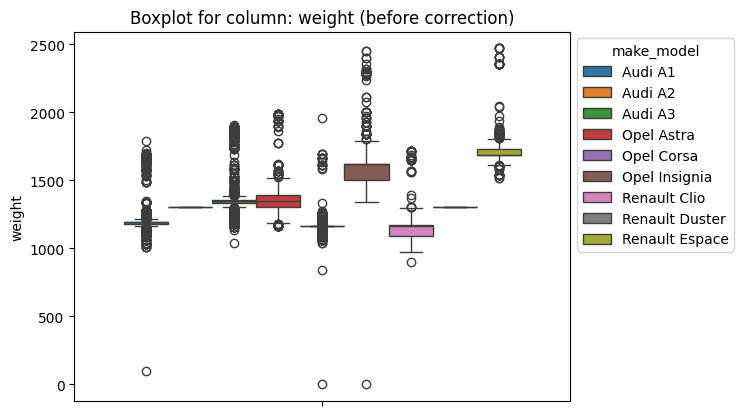

In [13]:
ax =sns.boxplot(df, y='weight', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: weight (before correction)');

In [14]:
df['weight'].describe()

,weight
count,15919.000000
mean,1345.508857
std,203.265691
min,1.000000
25%,1180.000000
50%,1308.000000
75%,1472.000000
max,2471.000000


In [15]:
df.loc[df['weight'] < 500, 'weight']

,weight
1143,102.0
8355,1.0
12779,1.0


In [16]:
df.loc[df['weight'] < 500]

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
1143,Audi A1,Compact,VAT deductible,1.0,Used,Yes,Beige,Metallic,Cloth,Black,Automatic,Gasoline,102.0,Euro 6,4.0,Front,4.6,5.6,4.0,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Catalytic Converter,Sport seats,S...",19229,8263.0,70.0,999.0,36.0,102.0,5.0,4.0,3.0,7.0,1.0
8355,Opel Corsa,Compact,Missing,1.0,Used,Yes,Silver,Metallic,Cloth,Black,Automatic,Gasoline,112.0,Euro 6,4.0,Front,4.8,5.8,4.1,Germany,Radio,"ABS,Central door lock,Daytime running lights,D...","Air conditioning,Electrical side mirrors,Hill ...",Catalytic Converter,12945,2015.0,66.0,1398.0,0.0,1.0,5.0,5.0,4.0,5.0,1.0
12779,Opel Insignia,Station wagon,VAT deductible,0.0,New,No,Black,Metallic,Cloth,Black,Manual,Gasoline,124.0,Euro 6,4.0,Front,6.1,7.6,5.2,Netherlands,"Bluetooth,Hands-free equipment,On-board comput...","Fog lights,Lane departure warning system","Heated steering wheel,Hill Holder,Park Distanc...","Alloy wheels,Roof rack",39299,10.0,121.0,1500.0,0.0,1.0,5.0,5.0,4.0,6.0,0.0


In [17]:
df.loc[df['weight'] < 500, 'weight'] = np.nan
df['weight'].isnull().sum()

np.int64(3)

In [18]:
df_tmp = fill_two_stage(df, 'make_model', 'body_type', 'weight', 'median')
df_tmp['weight'].isnull().sum()
df['weight'] = df_tmp['weight']

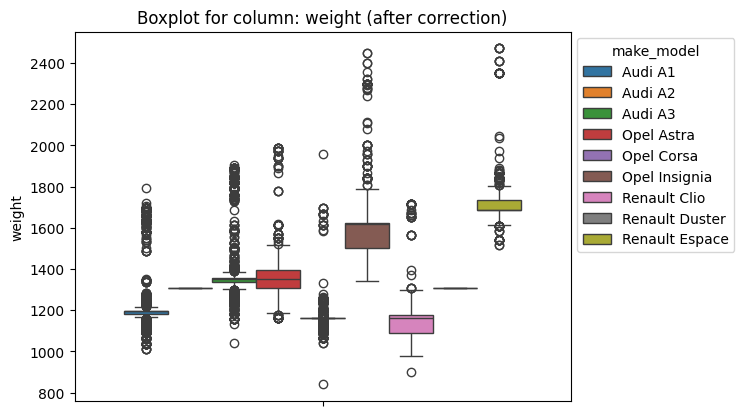

In [19]:
ax =sns.boxplot(df, y='weight', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: weight (after correction)');

#### Column: gears

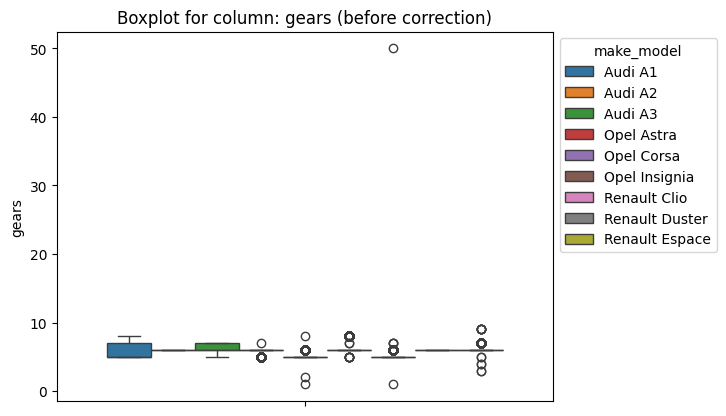

In [20]:
ax =sns.boxplot(df, y='gears', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1));
ax.set_title('Boxplot for column: gears (before correction)');

In [21]:
df['gears'].value_counts(dropna=False)

,count
gears,
6.0,8407
5.0,5363
7.0,1911
8.0,224
9.0,6
1.0,2
4.0,2
3.0,2
2.0,1


In [22]:
df.loc[df['gears'] > 10, 'gears'] = 5

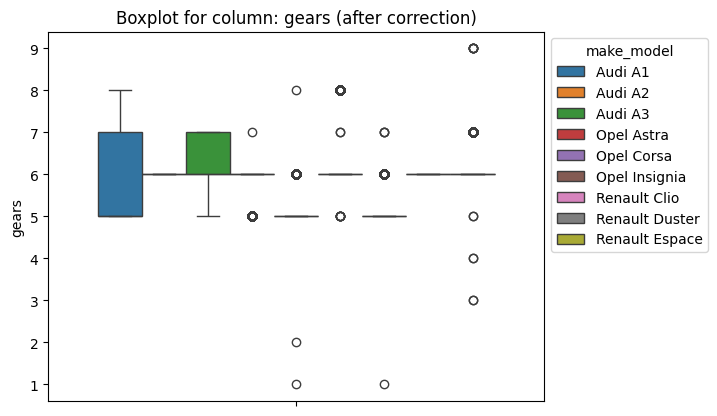

In [23]:
ax =sns.boxplot(df, y='gears', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: gears (after correction)');

#### Column: cylinders

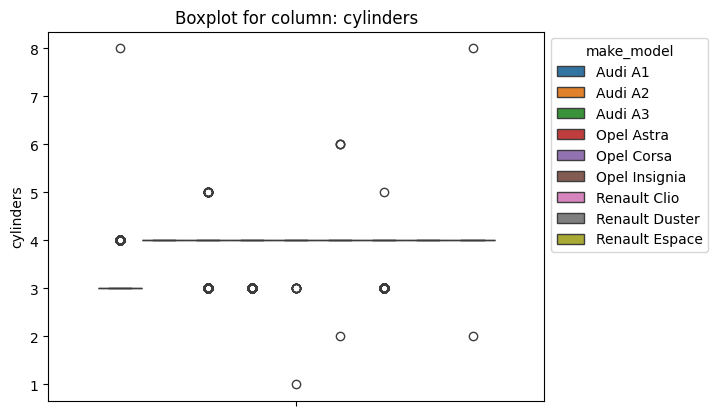

In [24]:
ax =sns.boxplot(df, y='cylinders', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: cylinders');

In [25]:
df['cylinders'].value_counts(dropna=False)

,count
cylinders,
4.0,12926
3.0,2963
5.0,22
6.0,3
8.0,2
2.0,2
1.0,1


#### Column: hp


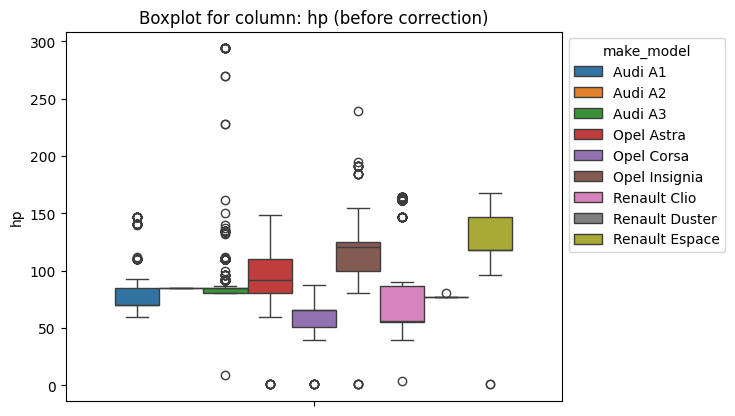

In [26]:
ax =sns.boxplot(df, y='hp', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: hp (before correction)');

In [27]:
df['hp'].describe()

,hp
count,15919.000000
mean,88.372385
std,26.840256
min,1.000000
25%,66.000000
50%,85.000000
75%,101.000000
max,294.000000


In [28]:
df.loc[df['hp'] < 10, 'hp']

,hp
3913,9.0
6005,1.0
6034,1.0
6946,1.0
7014,1.0
7016,1.0
7018,1.0
7019,1.0
9285,1.0
9287,1.0


In [29]:
df.loc[df['hp'] < 10, 'hp'] = np.nan
df['hp'].isnull().sum()

np.int64(22)

In [30]:
df_tmp = fill_two_stage(df, 'make_model', 'body_type', 'hp', 'median')
df_tmp['hp'].isnull().sum()
df['hp'] = df_tmp['hp']

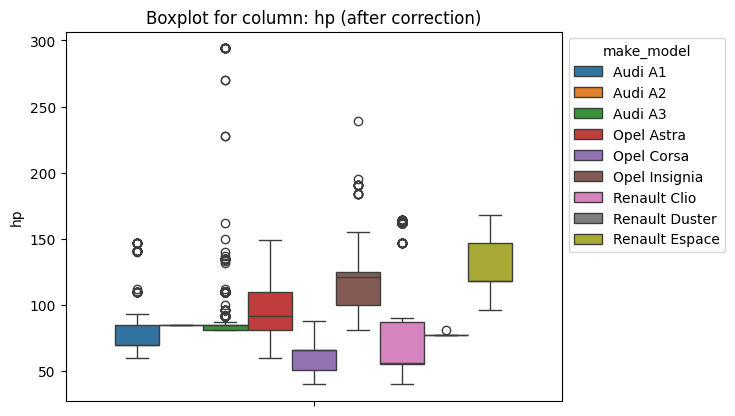

In [31]:
ax =sns.boxplot(df, y='hp', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: hp (after correction)');

#### Column: displacement


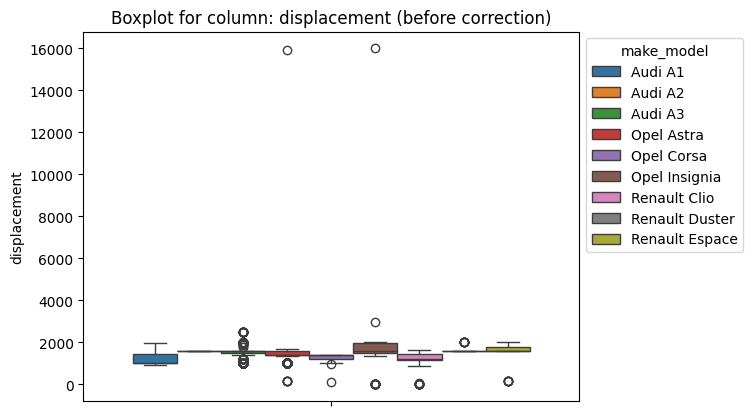

In [32]:
ax =sns.boxplot(df, y='displacement', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: displacement (before correction)');

In [33]:
df['displacement'].describe()

,displacement
count,15919.000000
mean,1425.250801
std,329.795709
min,1.000000
25%,1229.000000
50%,1461.000000
75%,1598.000000
max,16000.000000


In [34]:
df.loc[df['displacement'] > 4000, 'displacement']

,displacement
7169,15898.0
10932,16000.0


In [35]:
df.loc[df['displacement'] > 4000]

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
7169,Opel Astra,Station wagon,VAT deductible,1.0,Employee's car,Yes,Green,Metallic,Cloth,Black,Automatic,Gasoline,119.0,Euro 6,4.0,Front,4.5,5.7,3.8,Germany,"Bluetooth,Hands-free equipment,MP3,On-board co...","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Touch screen,Voice Control",18490,22327.0,100.0,15898.0,0.0,1393.0,5.0,5.0,4.0,6.0,1.0
10932,Opel Insignia,Station wagon,Price negotiable,1.0,Used,No,Grey,Metallic,Full leather,Black,Manual,Diesel,104.0,Euro 6,4.0,Front,5.1,6.5,4.2,Germany,"Bluetooth,Hands-free equipment,MP3,On-board co...","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Automatic climate control,Cru...","Alloy wheels,Touch screen,Voice Control",14300,76500.0,88.0,16000.0,0.0,1623.0,5.0,5.0,4.0,6.0,3.0


In [36]:
df.loc[7169,'displacement'] = round(df.loc[7169,'displacement'] / 10, 0)
df.loc[10932,'displacement'] = df.loc[10932,'displacement'] / 10

In [37]:
df.loc[df['displacement'] < 500, 'displacement']

,displacement
7809,139.0
7810,139.0
7811,139.0
7812,139.0
8128,140.0
10194,122.0
10559,2.0
12467,1.0
12473,1.0
12484,1.0


In [38]:
#df.loc[df['displacement'] < 500]

In [39]:
df.loc[df['displacement'] < 500, 'displacement'] = np.nan
df['displacement'].isnull().sum()

np.int64(51)

In [40]:
df_tmp = fill_two_stage(df, 'make_model', 'body_type', 'displacement', 'median')
df_tmp['displacement'].isnull().sum()
df['displacement'] = df_tmp['displacement']

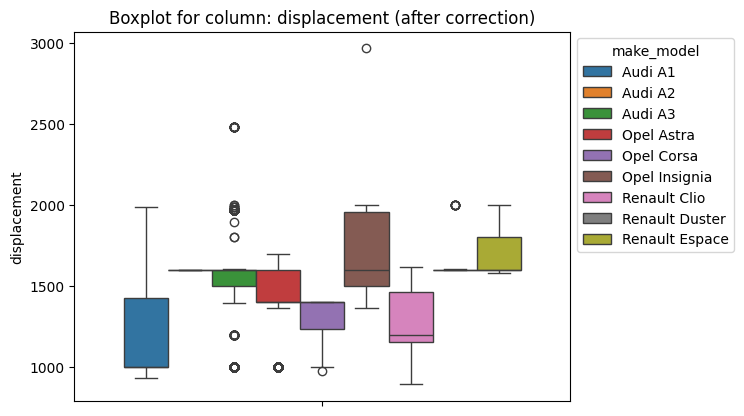

In [41]:
ax =sns.boxplot(df, y='displacement', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: displacement (after correction)');

#### Column: co2_emission

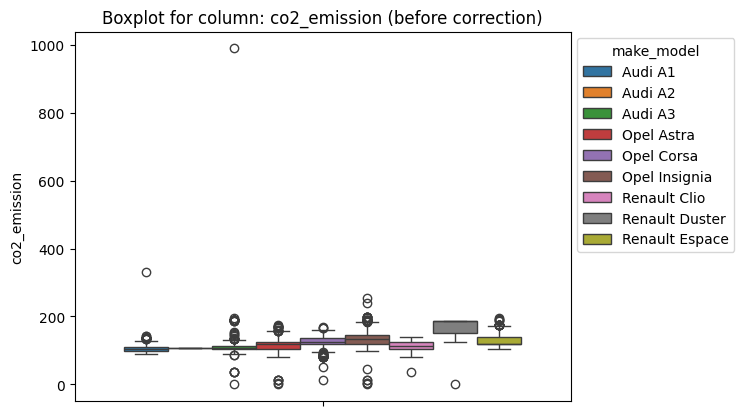

In [42]:
ax = sns.boxplot(df, y='co2_emission', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: co2_emission (before correction)');

In [43]:
df['co2_emission'].describe()

,co2_emission
count,15919.000000
mean,117.337207
std,19.024564
min,0.000000
25%,104.000000
50%,117.000000
75%,126.000000
max,990.000000


In [44]:
df.loc[df['co2_emission'] > 300]

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
535,Audi A1,Compact,Missing,1.0,Used,Yes,Silver,Metallic,Cloth,Black,Manual,Gasoline,331.0,Euro 4,4.0,Front,13.8,19.9,10.3,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Alarm system,Central door lock,Driver-side...","Air conditioning,Automatic climate control,Ele...","Ski bag,Sport suspension",12990,41200.0,70.0,999.0,0.0,1180.0,5.0,5.0,8.0,5.0,3.0
4556,Audi A3,Sedans,VAT deductible,1.0,Used,No,Grey,Metallic,Other,Other,Automatic,Diesel,990.0,Euro 6,1.0,Front,38.0,43.0,35.0,Italy,Bluetooth,"ABS,Central door lock,Power steering,Traction ...","Multi-function steering wheel,Park Distance Co...",Alloy wheels,23500,27815.0,81.0,1598.0,0.0,1350.0,5.0,5.0,4.0,6.0,1.0


In [45]:
df.loc[df['co2_emission'] > 300, 'co2_emission'] = np.nan
df['co2_emission'].isnull().sum()

np.int64(2)

In [46]:
df_tmp = fill_two_stage(df, 'fuel', 'age', 'co2_emission', 'mean')
df_tmp['co2_emission'].isnull().sum()
df['co2_emission'] = df_tmp['co2_emission']

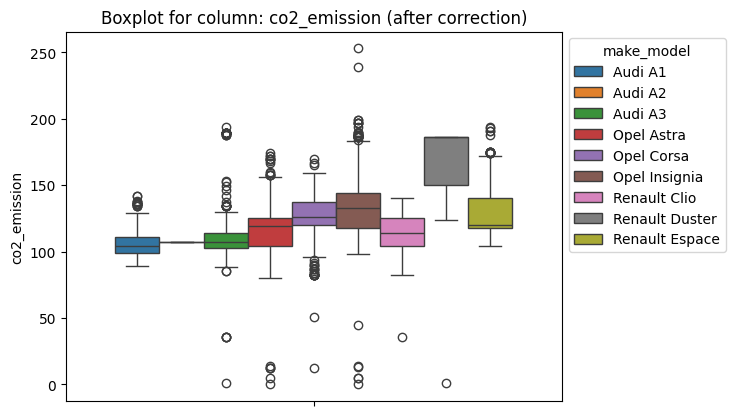

In [47]:
ax = sns.boxplot(df, y='co2_emission', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: co2_emission (after correction)');

#### Column: consumption_comb

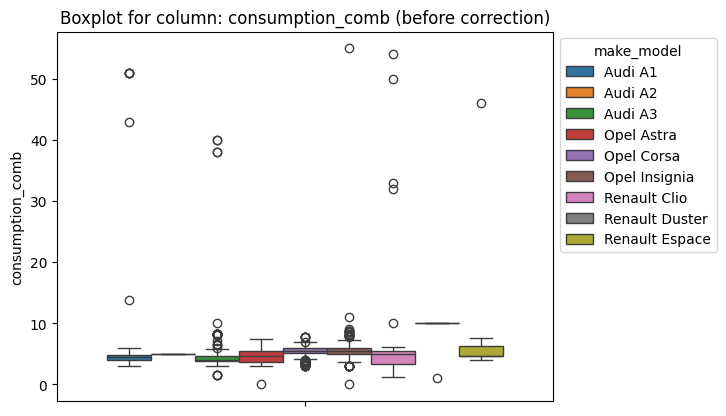

In [48]:
ax = sns.boxplot(df, y='consumption_comb', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1));
ax.set_title('Boxplot for column: consumption_comb (before correction)');

In [49]:
df.loc[df['consumption_comb'] > 30, 'consumption_comb'] = df.loc[df['consumption_comb'] > 30, 'consumption_comb'] /10

In [50]:
df['consumption_comb'].describe()

,consumption_comb
count,15919.000000
mean,4.833077
std,0.927609
min,0.000000
25%,4.000000
50%,4.800000
75%,5.400000
max,13.800000


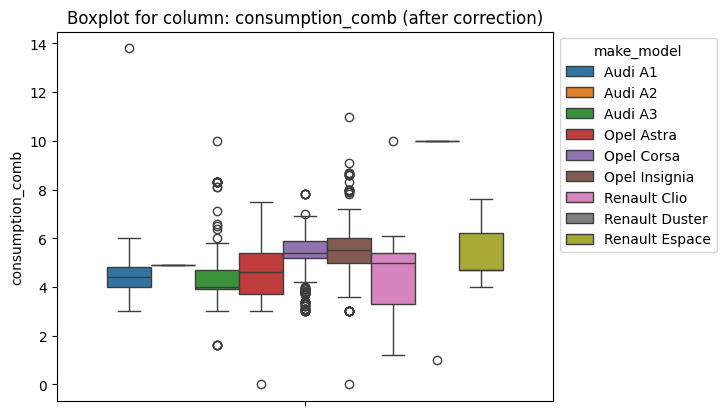

In [51]:
ax = sns.boxplot(df, y='consumption_comb', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1));
ax.set_title('Boxplot for column: consumption_comb (after correction)');

#### Column: consumption_city

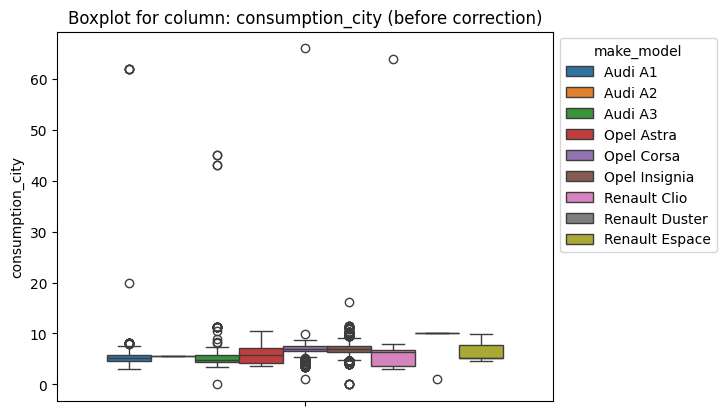

In [52]:
ax = sns.boxplot(df, y='consumption_city', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: consumption_city (before correction)');

In [53]:
df.loc[df['consumption_city'] > 30, 'consumption_city'] = df.loc[df['consumption_city'] > 30, 'consumption_city'] /10

In [54]:
df['consumption_city'].describe()

,consumption_city
count,15919.000000
mean,5.897007
std,1.393702
min,0.000000
25%,4.600000
50%,5.800000
75%,6.900000
max,19.900000


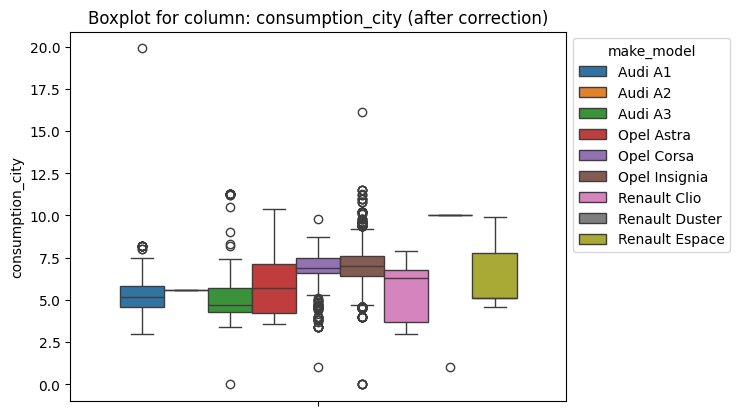

In [55]:
ax = sns.boxplot(df, y='consumption_city', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: consumption_city (after correction)');

#### Column: consumption_country

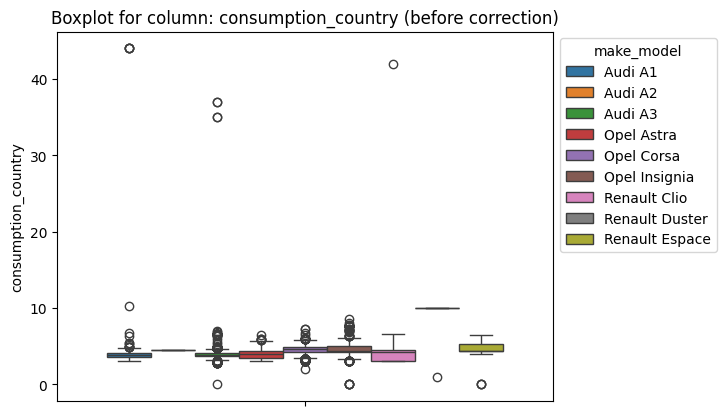

In [56]:
ax =sns.boxplot(df, y='consumption_country', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: consumption_country (before correction)');

In [57]:
df.loc[df['consumption_country'] > 30, 'consumption_country'] = df.loc[df['consumption_country'] > 30, 'consumption_country'] /10

In [58]:
df['consumption_country'].describe()

,consumption_country
count,15919.000000
mean,4.199095
std,0.721652
min,0.000000
25%,3.700000
50%,4.200000
75%,4.500000
max,10.300000


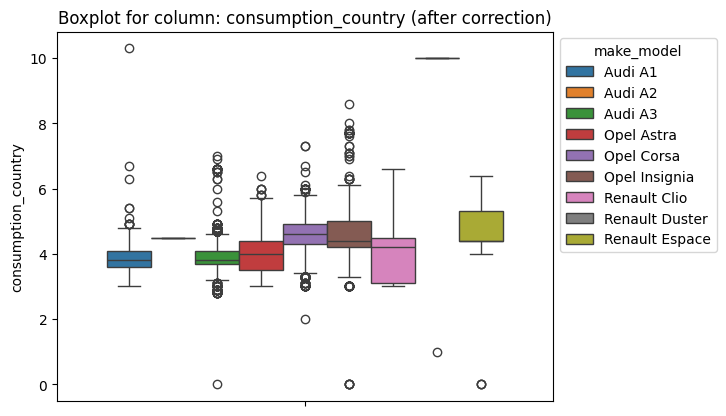

In [59]:
ax =sns.boxplot(df, y='consumption_country', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: consumption_country (after correction)');

#### Column: price

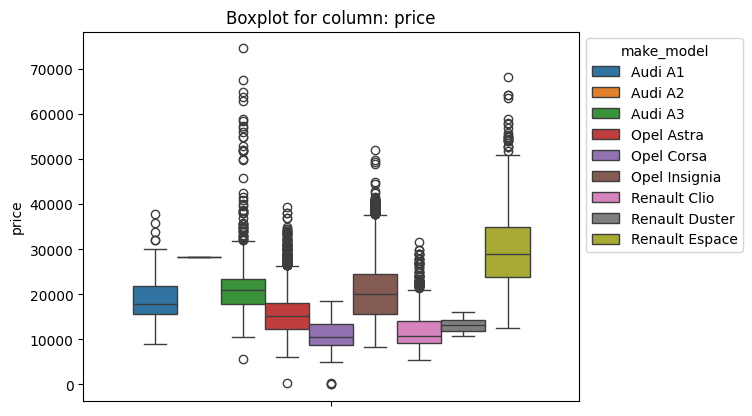

In [60]:
ax = sns.boxplot(df, y='price', hue='make_model')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title('Boxplot for column: price');

In [61]:
df.loc[df['price'] < 1000, 'price']

,price
6066,255
8594,13
8828,120
8829,331


In [62]:
df.loc[df['price'] < 1000]

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
6066,Opel Astra,Station wagon,Missing,1.0,Used,No,Gold,Metallic,Cloth,Black,Manual,Diesel,101.0,Euro 6,4.0,Front,3.8,4.5,3.4,Germany,"Bluetooth,Hands-free equipment,On-board comput...","ABS,Central door lock with remote control,Dayt...","Air conditioning,Cruise control,Electrical sid...",Roof rack,255,5563.0,100.0,1598.0,0.0,1403.0,5.0,5.0,4.0,6.0,1.0
8594,Opel Corsa,Sedans,Missing,1.0,Used,No,Gold,Metallic,Cloth,Black,Manual,Gasoline,128.0,Euro 6,4.0,Front,5.6,6.8,4.9,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Adaptive headlights,Central door lock with...","Air conditioning,Cruise control,Electrical sid...",Alloy wheels,13,123.0,66.0,1398.0,0.0,1141.0,3.0,5.0,4.0,5.0,1.0
8828,Opel Corsa,Compact,Missing,0.0,New,No,Grey,Metallic,Cloth,Black,Manual,Gasoline,107.0,Euro 6,4.0,Front,4.6,5.6,4.1,Netherlands,"Digital radio,On-board computer,Radio","Central door lock,Daytime running lights,Drive...","Air conditioning,Automatic climate control,Cru...","Alloy wheels,Sport suspension",120,12.0,66.0,999.0,0.0,1099.0,5.0,5.0,3.0,6.0,0.0
8829,Opel Corsa,Other,Missing,0.0,New,No,White,Metallic,Cloth,Black,Manual,Gasoline,124.0,Euro 6,4.0,Front,5.4,6.9,4.6,Netherlands,"Hands-free equipment,On-board computer,Radio","ABS,Central door lock,Driver-side airbag,Elect...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Sport package",331,10.0,66.0,999.0,0.0,1163.0,5.0,5.0,3.0,6.0,0.0


In [63]:
df.drop(df[df['price'] < 1000].index, inplace=True)

### Dataset export

In [64]:
df.head()

,make_model,body_type,vat,prev_owner,type,inspection_new,body_color,paint_type,upholstery_texture,upholstery_color,gearing_type,fuel,co2_emission,emission_class,emission_label,drive_chain,consumption_comb,consumption_city,consumption_country,country_version,entertainment_media,safety_security,comfort_convenience,extras,price,km,hp,displacement,warranty,weight,nr_of_doors,nr_of_seats,cylinders,gears,age
0,Audi A1,Sedans,VAT deductible,2.0,Used,Yes,Black,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.3,3.5,Germany,"Bluetooth,Hands-free equipment,On-board comput...","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Catalytic Converter,Voice Control",15770,56013.0,66.0,1422.0,0.0,1220.0,5.0,5.0,3.0,5.0,3.0
1,Audi A1,Sedans,Price negotiable,1.0,Used,No,Red,Metallic,Cloth,Grey,Automatic,Gasoline,129.0,Euro 6,4.0,Front,5.6,7.1,4.7,Germany,"Bluetooth,Hands-free equipment,On-board comput...","ABS,Central door lock,Central door lock with r...","Air conditioning,Automatic climate control,Hil...","Alloy wheels,Sport seats,Sport suspension,Voic...",14500,80000.0,141.0,1798.0,0.0,1255.0,3.0,4.0,4.0,7.0,2.0
2,Audi A1,Sedans,VAT deductible,1.0,Used,No,Black,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.4,3.4,Germany,"MP3,On-board computer","ABS,Central door lock,Daytime running lights,D...","Air conditioning,Cruise control,Electrical sid...","Alloy wheels,Voice Control",14640,83450.0,85.0,1598.0,0.0,1195.0,4.0,4.0,3.0,5.0,3.0
3,Audi A1,Sedans,Missing,1.0,Used,No,Brown,Metallic,Cloth,Black,Automatic,Diesel,99.0,Euro 6,4.0,Front,3.8,4.3,3.5,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Alarm system,Central door lock with remote...","Air suspension,Armrest,Auxiliary heating,Elect...","Alloy wheels,Sport seats,Voice Control",14500,73000.0,66.0,1422.0,0.0,1195.0,3.0,4.0,3.0,6.0,3.0
4,Audi A1,Sedans,Missing,1.0,Used,Yes,Black,Metallic,Cloth,Black,Automatic,Diesel,109.0,Euro 6,4.0,Front,4.1,4.6,3.8,Germany,"Bluetooth,CD player,Hands-free equipment,MP3,O...","ABS,Central door lock,Driver-side airbag,Elect...","Air conditioning,Armrest,Automatic climate con...","Alloy wheels,Sport package,Sport suspension,Vo...",16790,16200.0,66.0,1422.0,0.0,1195.0,5.0,5.0,3.0,5.0,3.0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15915 entries, 0 to 15918
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   vat                  15915 non-null  object 
 3   prev_owner           15915 non-null  float64
 4   type                 15915 non-null  object 
 5   inspection_new       15915 non-null  object 
 6   body_color           15915 non-null  object 
 7   paint_type           15915 non-null  object 
 8   upholstery_texture   15915 non-null  object 
 9   upholstery_color     15915 non-null  object 
 10  gearing_type         15915 non-null  object 
 11  fuel                 15915 non-null  object 
 12  co2_emission         15915 non-null  float64
 13  emission_class       15915 non-null  object 
 14  emission_label       15915 non-null  float64
 15  drive_chain          15915 non-null  obje

In [66]:
df.to_csv(drive_data_dir+'/data_to_encode.csv', index=False)